# Regression in Python

***
This is a very quick run-through of some basic statistical concepts, adapted from [Lab 4 in Harvard's CS109](https://github.com/cs109/2015lab4) course. Please feel free to try the original lab if you're feeling ambitious :-) The CS109 git repository also has the solutions if you're stuck.

* Linear Regression Models
* Prediction using linear regression

Linear regression is used to model and predict continuous outcomes with normal random errors. There are nearly an infinite number of different types of regression models and each regression model is typically defined by the distribution of the prediction errors (called "residuals") of the type of data. Logistic regression is used to model binary outcomes whereas Poisson regression is used to predict counts. In this exercise, we'll see some examples of linear regression as well as Train-test splits.

The packages we'll cover are: `statsmodels`, `seaborn`, and `scikit-learn`. While we don't explicitly teach `statsmodels` and `seaborn` in the Springboard workshop, those are great libraries to know.
***

<img width=600 height=300 src="https://imgs.xkcd.com/comics/sustainable.png"/>
***

In [1]:
# special IPython command to prepare the notebook for matplotlib and other libraries
%matplotlib inline 

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import sklearn

import seaborn as sns

# special matplotlib argument for improved plots
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")


***
# Part 1: Introduction to Linear Regression
### Purpose of linear regression
***
<div class="span5 alert alert-info">

<p> Given a dataset containing predictor variables $X$ and outcome/response variable $Y$, linear regression can be used to: </p>
<ul>
  <li> Build a <b>predictive model</b> to predict future values of $\hat{Y}$, using new data $X^*$ where $Y$ is unknown.</li>
  <li> Model the <b>strength of the relationship</b> between each independent variable $X_i$ and $Y$</li>
    <ul>
      <li> Many times, only a subset of independent variables $X_i$ will have a linear relationship with $Y$</li>
      <li> Need to figure out which $X_i$ contributes most information to predict $Y$ </li>
    </ul>
   <li>It is in many cases, the first pass prediction algorithm for continuous outcomes. </li>
</ul>
</div>

### A Brief Mathematical Recap
***

[Linear Regression](http://en.wikipedia.org/wiki/Linear_regression) is a method to model the relationship between a set of independent variables $X$ (also knowns as explanatory variables, features, predictors) and a dependent variable $Y$.  This method assumes the relationship between each predictor $X$ is **linearly** related to the dependent variable $Y$. The most basic linear regression model contains one independent variable $X$, we'll call this the simple model. 

$$ Y = \beta_0 + \beta_1 X + \epsilon$$

where $\epsilon$ is considered as an unobservable random variable that adds noise to the linear relationship. In linear regression, $\epsilon$ is assumed to be normally distributed with a mean of 0. In other words, what this means is that on average, if we know $Y$, a roughly equal number of predictions $\hat{Y}$ will be above $Y$ and others will be below $Y$. That is, on average, the error is zero. The residuals, $\epsilon$ are also assumed to be "i.i.d.": independently and identically distributed. Independence means that the residuals are not correlated -- the residual from one prediction has no effect on the residual from another prediction. Correlated errors are common in time series analysis and spatial analyses.

* $\beta_0$ is the intercept of the linear model and represents the average of $Y$ when all independent variables $X$ are set to 0.

* $\beta_1$ is the slope of the line associated with the regression model and represents the average effect of a one-unit increase in $X$ on $Y$.

* Back to the simple model. The model in linear regression is the *conditional mean* of $Y$ given the values in $X$ is expressed a linear function.  

$$ y = f(x) = E(Y | X = x)$$ 

![conditional mean](images/conditionalmean.png)
*Image from http://www.learner.org/courses/againstallodds/about/glossary.html. Note this image uses $\alpha$ and $\beta$ instead of $\beta_0$ and $\beta_1$.*

* The goal is to estimate the coefficients (e.g. $\beta_0$ and $\beta_1$). We represent the estimates of the coefficients with a "hat" on top of the letter.  

$$ \hat{\beta}_0, \hat{\beta}_1 $$

* Once we estimate the coefficients $\hat{\beta}_0$ and $\hat{\beta}_1$, we can use these to predict new values of $Y$ given new data $X$.

$$\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x_1$$

* Multiple linear regression is when you have more than one independent variable and the estimation involves matrices
    * $X_1$, $X_2$, $X_3$, $\ldots$


* How do you estimate the coefficients? 
    * There are many ways to fit a linear regression model
    * The method called **least squares** is the most common methods
    * We will discuss least squares

$$ Y = \beta_0 + \beta_1 X_1 + \ldots + \beta_p X_p + \epsilon$$ 
    
### Estimating $\hat\beta$: Least squares
***
[Least squares](http://en.wikipedia.org/wiki/Least_squares) is a method that can estimate the coefficients of a linear model by minimizing the squared residuals: 

$$ \mathscr{L} = \sum_{i=1}^N \epsilon_i^2 = \sum_{i=1}^N \left( y_i - \hat{y}_i \right)^2  = \sum_{i=1}^N \left(y_i - \left(\beta_0 + \beta_1 x_i\right)\right)^2 $$

where $N$ is the number of observations and $\epsilon$ represents a residual or error, ACTUAL - PREDICTED.  

#### Estimating the intercept $\hat{\beta_0}$ for the simple linear model

We want to minimize the squared residuals and solve for $\hat{\beta_0}$ so we take the partial derivative of $\mathscr{L}$ with respect to $\hat{\beta_0}$ 

$
\begin{align}
\frac{\partial \mathscr{L}}{\partial \hat{\beta_0}} &= \frac{\partial}{\partial \hat{\beta_0}} \sum_{i=1}^N \epsilon^2 \\
&= \frac{\partial}{\partial \hat{\beta_0}} \sum_{i=1}^N \left( y_i - \hat{y}_i \right)^2 \\
&= \frac{\partial}{\partial \hat{\beta_0}} \sum_{i=1}^N \left( y_i - \left( \hat{\beta}_0 + \hat{\beta}_1 x_i \right) \right)^2 \\
&= -2 \sum_{i=1}^N \left( y_i - \left( \hat{\beta}_0 + \hat{\beta}_1 x_i \right) \right) \hspace{25mm} \mbox{(by chain rule)} \\
&= -2 \sum_{i=1}^N (y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i) \\
&= -2 \left[ \left( \sum_{i=1}^N y_i \right) - N \hat{\beta_0} - \hat{\beta}_1 \left( \sum_{i=1}^N x_i
\right) \right] \\
& 2 \left[ N \hat{\beta}_0 + \hat{\beta}_1 \sum_{i=1}^N x_i - \sum_{i=1}^N y_i \right] = 0 \hspace{20mm} \mbox{(Set equal to 0 and solve for $\hat{\beta}_0$)} \\
& N \hat{\beta}_0 + \hat{\beta}_1 \sum_{i=1}^N x_i - \sum_{i=1}^N y_i = 0 \\
& N \hat{\beta}_0 = \sum_{i=1}^N y_i - \hat{\beta}_1 \sum_{i=1}^N x_i \\
& \hat{\beta}_0 = \frac{\sum_{i=1}^N y_i - \hat{\beta}_1 \sum_{i=1}^N x_i}{N} \\
& \hat{\beta}_0 = \frac{\sum_{i=1}^N y_i}{N} - \hat{\beta}_1 \frac{\sum_{i=1}^N x_i}{N} \\
& \boxed{\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}}
\end{align}
$

Using this new information, we can compute the estimate for $\hat{\beta}_1$ by taking the partial derivative of $\mathscr{L}$ with respect to $\hat{\beta}_1$.

$
\begin{align}
\frac{\partial \mathscr{L}}{\partial \hat{\beta_1}} &= \frac{\partial}{\partial \hat{\beta_1}} \sum_{i=1}^N \epsilon^2 \\
&= \frac{\partial}{\partial \hat{\beta_1}} \sum_{i=1}^N \left( y_i - \hat{y}_i \right)^2 \\
&= \frac{\partial}{\partial \hat{\beta_1}} \sum_{i=1}^N \left( y_i - \left( \hat{\beta}_0 + \hat{\beta}_1 x_i \right) \right)^2 \\
&= 2 \sum_{i=1}^N \left( y_i - \left( \hat{\beta}_0 + \hat{\beta}_1 x_i \right) \right) \left( -x_i \right) \hspace{25mm}\mbox{(by chain rule)} \\
&= -2 \sum_{i=1}^N x_i \left( y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i \right) \\
&= -2 \sum_{i=1}^N x_i (y_i - \hat{\beta}_0 x_i - \hat{\beta}_1 x_i^2) \\
&= -2 \sum_{i=1}^N x_i (y_i - \left( \bar{y} - \hat{\beta}_1 \bar{x} \right) x_i - \hat{\beta}_1 x_i^2) \\
&= -2 \sum_{i=1}^N (x_i y_i - \bar{y}x_i + \hat{\beta}_1\bar{x}x_i - \hat{\beta}_1 x_i^2) \\
&= -2 \left[ \sum_{i=1}^N x_i y_i - \bar{y} \sum_{i=1}^N x_i + \hat{\beta}_1\bar{x}\sum_{i=1}^N x_i - \hat{\beta}_1 \sum_{i=1}^N x_i^2 \right] \\
&= -2 \left[ \hat{\beta}_1 \left\{ \bar{x} \sum_{i=1}^N x_i - \sum_{i=1}^N x_i^2 \right\} + \left\{ \sum_{i=1}^N x_i y_i - \bar{y} \sum_{i=1}^N x_i \right\}\right] \\
& 2 \left[ \hat{\beta}_1 \left\{ \sum_{i=1}^N x_i^2 - \bar{x} \sum_{i=1}^N x_i \right\} + \left\{ \bar{y} \sum_{i=1}^N x_i - \sum_{i=1}^N x_i y_i \right\} \right] = 0 \\
& \hat{\beta}_1 = \frac{-\left( \bar{y} \sum_{i=1}^N x_i - \sum_{i=1}^N x_i y_i \right)}{\sum_{i=1}^N x_i^2 - \bar{x}\sum_{i=1}^N x_i} \\
&= \frac{\sum_{i=1}^N x_i y_i - \bar{y} \sum_{i=1}^N x_i}{\sum_{i=1}^N x_i^2 - \bar{x} \sum_{i=1}^N x_i} \\
& \boxed{\hat{\beta}_1 = \frac{\sum_{i=1}^N x_i y_i - \bar{x}\bar{y}n}{\sum_{i=1}^N x_i^2 - n \bar{x}^2}}
\end{align}
$

The solution can be written in compact matrix notation as

$$\hat\beta =  (X^T X)^{-1}X^T Y$$ 

We wanted to show you this in case you remember linear algebra, in order for this solution to exist we need $X^T X$ to be invertible. Of course this requires a few extra assumptions, $X$ must be full rank so that $X^T X$ is invertible, etc. Basically, $X^T X$ is full rank if all rows and columns are linearly independent. This has a loose relationship to variables and observations being independent respective. **This is important for us because this means that having redundant features in our regression models will lead to poorly fitting (and unstable) models.** We'll see an implementation of this in the extra linear regression example.

***
# Part 2: Exploratory Data Analysis for Linear Relationships

The [Boston Housing data set](https://archive.ics.uci.edu/ml/datasets/Housing) contains information about the housing values in suburbs of Boston.  This dataset was originally taken from the StatLib library which is maintained at Carnegie Mellon University and is now available on the UCI Machine Learning Repository. 


## Load the Boston Housing data set from `sklearn`
***

This data set is available in the [sklearn](http://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_boston.html#sklearn.datasets.load_boston) python module which is how we will access it today.  

In [2]:
import pandas as pd

bos = pd.read_csv('boston.csv')
print(bos.shape)
bos.head()

(506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


Now we have a pandas DataFrame called `bos` containing all the data we want to use to predict Boston Housing prices.  Let's rename the target variable of `MEDV` to `PRICE` which will contain the prices. 

In [3]:
bos = bos.rename(columns={"MEDV":"PRICE"})
bos.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


## EDA and Summary Statistics
***

Let's explore this data set.  First we use `describe()` to get basic summary statistics for each of the columns. 

In [4]:
bos.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### Scatterplots
***

Let's look at some scatter plots for three variables: 'CRIM' (per capita crime rate), 'RM' (number of rooms) and 'PTRATIO' (pupil-to-teacher ratio in schools).  

Text(0.5, 1.0, 'Relationship between CRIM and Price')

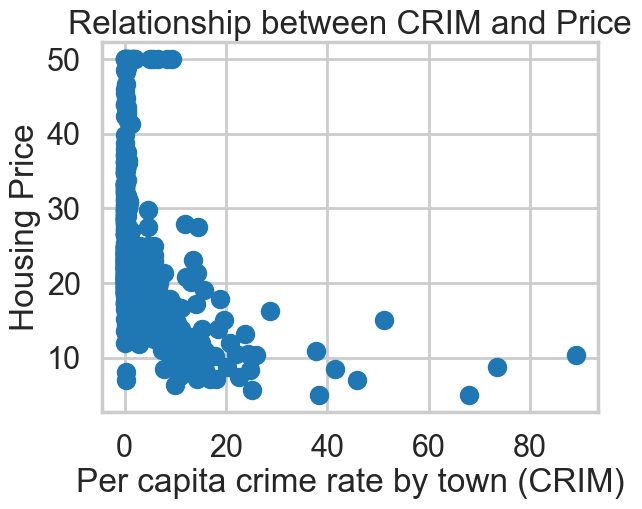

In [5]:
plt.scatter(bos.CRIM, bos.PRICE)
plt.xlabel("Per capita crime rate by town (CRIM)")
plt.ylabel("Housing Price")
plt.title("Relationship between CRIM and Price")

<div class="span5 alert alert-info">
<h3>Part 2 Checkup Exercise Set I</h3>

<p><b>Exercise:</b> What kind of relationship do you see? e.g. positive, negative?  linear? non-linear? Is there anything else strange or interesting about the data? What about outliers?</p>


<p><b>Exercise:</b> Create scatter plots between *RM* and *PRICE*, and *PTRATIO* and *PRICE*. Label your axes appropriately using human readable labels. Tell a story about what you see.</p>

<p><b>Exercise:</b> What are some other numeric variables of interest? Why do you think they are interesting? Plot scatterplots with these variables and *PRICE* (house price) and tell a story about what you see.</p>

</div>

### your turn: describe relationship
<p><b>Answer:</b> The relationship between CRIM and PRICE is generally negative and nonlinear. As the per capita crime rate increases, housing prices tend to decrease. The data become more spread out at higher crime rates, and there are some potential outliers with unusually high crime rates and low housing prices.



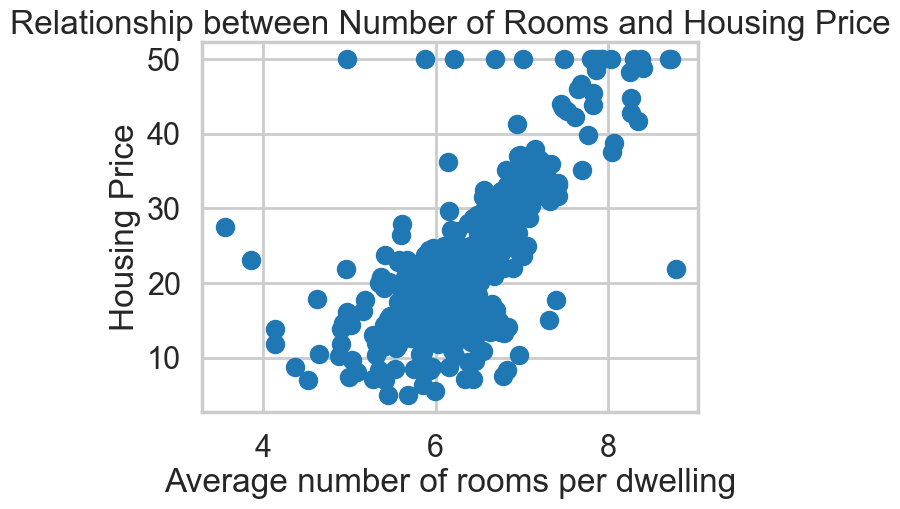

In [6]:
# your turn: scatter plot between *RM* and *PRICE*

# Plot average number of rooms versus housing price
plt.scatter(bos['RM'], bos['PRICE'])

# Add labels and title
plt.xlabel('Average number of rooms per dwelling')
plt.ylabel('Housing Price')
plt.title('Relationship between Number of Rooms and Housing Price')

plt.show()

<p><b>Answer:</b> There is a strong positive relationship between RM and PRICE. In general, houses with more rooms tend to have higher prices. The relationship appears approximately linear, although there are some outliers and a ceiling effect at the highest housing prices.

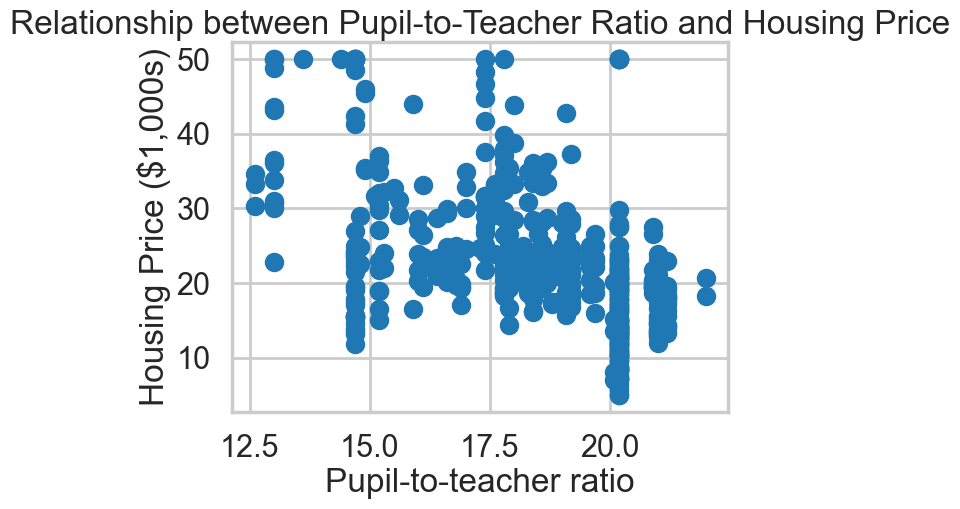

In [7]:
# your turn: scatter plot between *PTRATIO* and *PRICE*

# Plot pupil-to-teacher ratio versus housing price
plt.scatter(bos['PTRATIO'], bos['PRICE'])

# Add labels and title
plt.xlabel('Pupil-to-teacher ratio')
plt.ylabel('Housing Price ($1,000s)')
plt.title('Relationship between Pupil-to-Teacher Ratio and Housing Price')

plt.show()


<p><b>Answer:</b> PTRATIO and PRICE show a generally negative association: higher pupil-to-teacher ratios tend to be associated with lower housing prices. However, the relationship is weaker and more scattered than the relationship between RM and PRICE, so PTRATIO alone does not explain much of the variation in housing price.

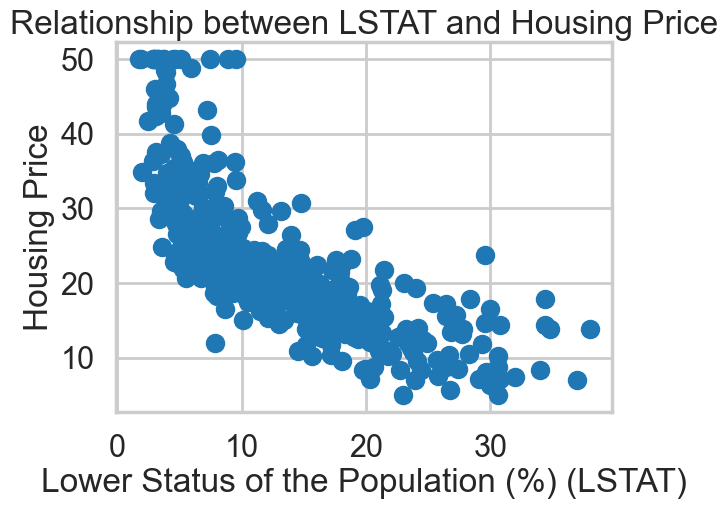

In [8]:
# your turn: create some other scatter plots

# Create a scatter plot showing the relationship between
# LSTAT and housing price.
# LSTAT is the percentage of the population with lower socioeconomic status.
plt.scatter(bos.LSTAT, bos.PRICE)

# Label the x-axis
plt.xlabel("Lower Status of the Population (%) (LSTAT)")

# Label the y-axis
plt.ylabel("Housing Price")

# Add a descriptive title
plt.title("Relationship between LSTAT and Housing Price")

# Display the plot
plt.show()


<p><b>Answer:</b> LSTAT has a strong negative and nonlinear association with PRICE. Higher LSTAT values tend to be associated with lower housing prices. The relationship is not perfectly linear, particularly at the extremes.

### Scatterplots using Seaborn
***

[Seaborn](https://stanford.edu/~mwaskom/software/seaborn/) is a cool Python plotting library built on top of matplotlib. It provides convenient syntax and shortcuts for many common types of plots, along with better-looking defaults.

We can also use [seaborn regplot](https://stanford.edu/~mwaskom/software/seaborn/tutorial/regression.html#functions-to-draw-linear-regression-models) for the scatterplot above. This provides automatic linear regression fits (useful for data exploration later on). Here's one example below.

<Axes: xlabel='RM', ylabel='PRICE'>

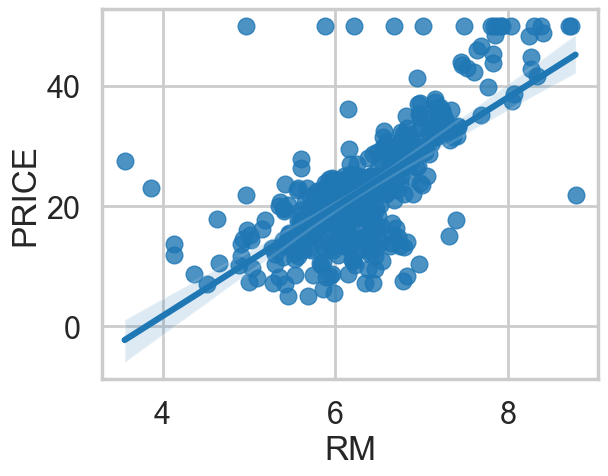

In [9]:
sns.regplot(y="PRICE", x="RM", data=bos, fit_reg = True)

### Histograms
***


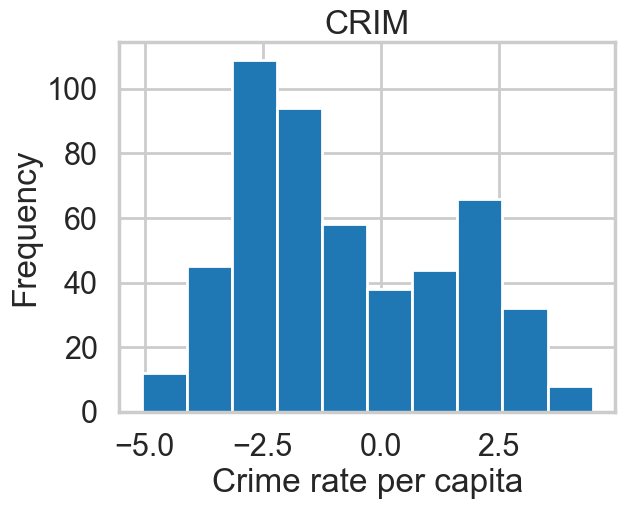

In [10]:
plt.hist(np.log(bos.CRIM))
plt.title("CRIM")
plt.xlabel("Crime rate per capita")
plt.ylabel("Frequency")
plt.show()

<div class="span5 alert alert-info">
<h3>Part 2 Checkup Exercise Set II</h3>

<p><b>Exercise:</b> In the above histogram, we took the logarithm of the crime rate per capita. Repeat this histogram without taking the log. What was the purpose of taking the log? What do we gain by making this transformation? What do you now notice about this variable that is not obvious without making the transformation?

<p><b>Exercise:</b> Plot the histogram for *RM* and *PTRATIO* against each other, along with the two variables you picked in the previous section. We are looking for correlations in predictors here.</p>
</div>

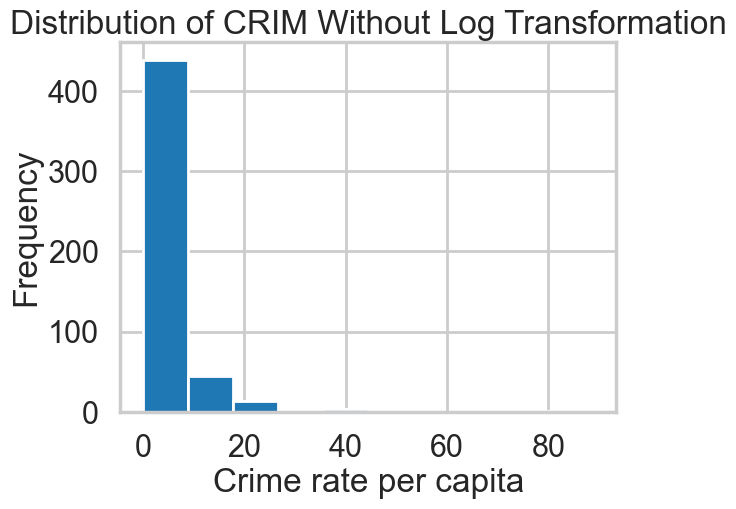

In [11]:
#your turn

# Plot the original CRIM variable without a logarithmic transformation
plt.hist(bos['CRIM'])

plt.xlabel('Crime rate per capita')
plt.ylabel('Frequency')
plt.title('Distribution of CRIM Without Log Transformation')

plt.show()

<p><b>Answer:</b> The log transformation compresses very large CRIM values and makes the lower and middle portions of the distribution easier to examine. It can also reduce skewness, which may be useful when modeling a strongly skewed predictor.

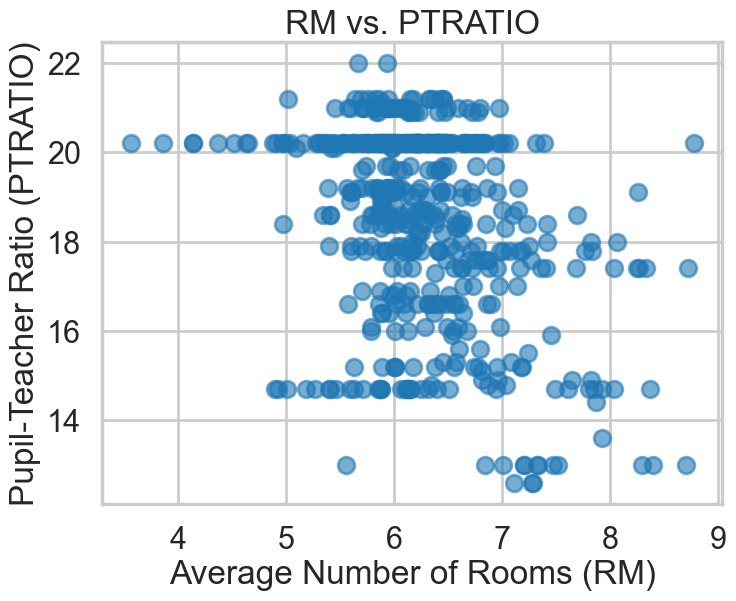

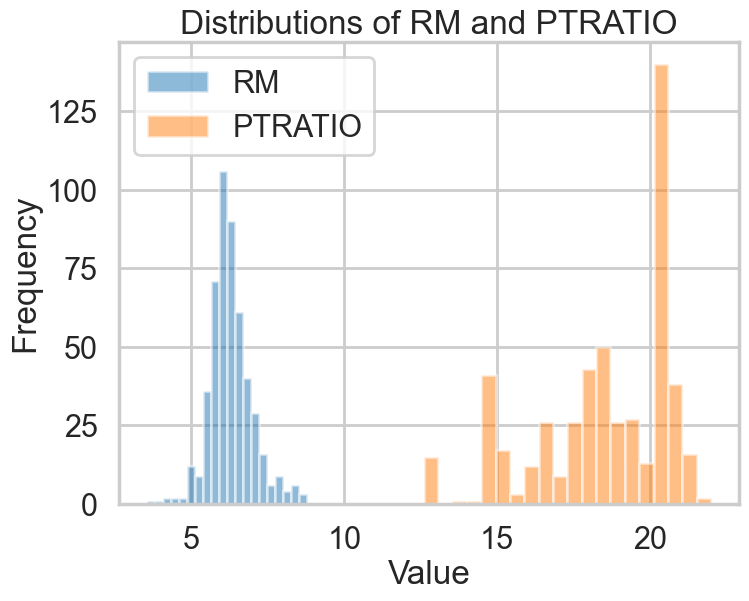

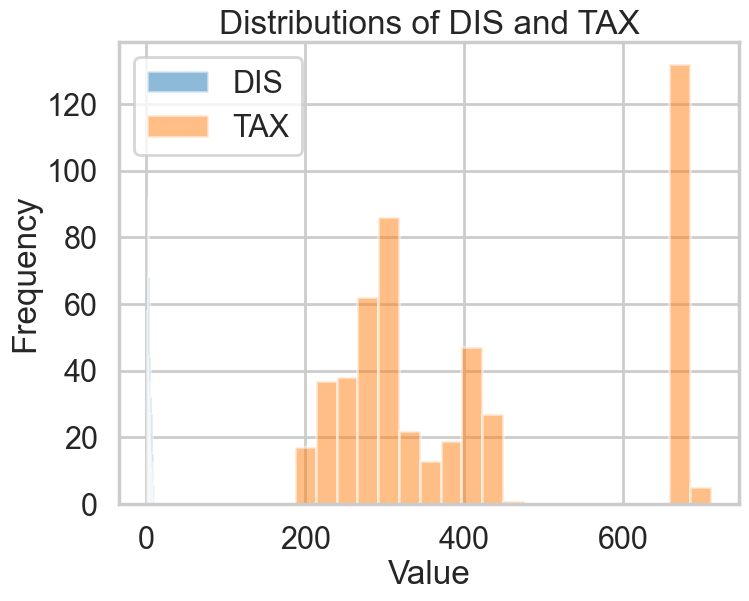

In [12]:
# Plot the relationship between RM and PTRATIO.
plt.figure(figsize=(8, 6))

plt.scatter(bos['RM'], bos['PTRATIO'], alpha=0.6)

plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('Pupil-Teacher Ratio (PTRATIO)')
plt.title('RM vs. PTRATIO')
plt.show()


# Plot the distributions of RM and PTRATIO.
plt.figure(figsize=(8, 6))

plt.hist(bos['RM'], bins=20, alpha=0.5, label='RM')
plt.hist(bos['PTRATIO'], bins=20, alpha=0.5, label='PTRATIO')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distributions of RM and PTRATIO')
plt.legend()
plt.show()


# Plot the distributions of the two additional predictors: DIS and TAX.
plt.figure(figsize=(8, 6))

plt.hist(bos['DIS'], bins=20, alpha=0.5, label='DIS')
plt.hist(bos['TAX'], bins=20, alpha=0.5, label='TAX')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distributions of DIS and TAX')
plt.legend()
plt.show()

<p><b>Answer:</b> The histograms show the distributions of the four predictor variables, but they do not directly measure correlation between predictors. The scatterplot of RM and PTRATIO provides a visual comparison of two predictors, while correlation coefficients could be used to quantify the strength of their relationships. Strong correlations between predictors can indicate multicollinearity, which may make individual regression coefficients more difficult to interpret.

## Part 3: Linear Regression with Boston Housing Data Example
***

Here, 

$Y$ = boston housing prices (called "target" data in python, and referred to as the dependent variable or response variable)

and

$X$ = all the other features (or independent variables, predictors or explanatory variables)

which we will use to fit a linear regression model and predict Boston housing prices. We will use the least-squares method to estimate the coefficients.  

We'll use two ways of fitting a linear regression. We recommend the first but the second is also powerful in its features.

### Fitting Linear Regression using `statsmodels`
***
[Statsmodels](http://statsmodels.sourceforge.net/) is a great Python library for a lot of basic and inferential statistics. It also provides basic regression functions using an R-like syntax, so it's commonly used by statisticians. While we don't cover statsmodels officially in the Data Science Intensive workshop, it's a good library to have in your toolbox. Here's a quick example of what you could do with it. The version of least-squares we will use in statsmodels is called *ordinary least-squares (OLS)*. There are many other versions of least-squares such as [partial least squares (PLS)](https://en.wikipedia.org/wiki/Partial_least_squares_regression) and [weighted least squares (WLS)](https://en.wikipedia.org/wiki/Iteratively_reweighted_least_squares).

In [13]:
# Import regression modules
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [14]:
# statsmodels works nicely with pandas dataframes
# The thing inside the "quotes" is called a formula, a bit on that below
m = ols('PRICE ~ RM',bos).fit()
print(m.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     471.8
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           2.49e-74
Time:                        00:31:04   Log-Likelihood:                -1673.1
No. Observations:                 506   AIC:                             3350.
Df Residuals:                     504   BIC:                             3359.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -34.6706      2.650    -13.084      0.0

#### Interpreting coefficients

There is a ton of information in this output. But we'll concentrate on the coefficient table (middle table). We can interpret the `RM` coefficient (9.1021) by first noticing that the p-value (under `P>|t|`) is so small, basically zero. This means that the number of rooms, `RM`, is a statisticall significant predictor of `PRICE`. The regression coefficient for `RM` of 9.1021 means that *on average, each additional room is associated with an increase of $\$9,100$ in house price net of the other variables*. The confidence interval gives us a range of plausible values for this average change, about ($\$8,279, \$9,925$), definitely not chump change. 

In general, the $\hat{\beta_i}, i > 0$ can be interpreted as the following: "A one unit increase in $x_i$ is associated with, on average, a $\hat{\beta_i}$ increase/decrease in $y$ net of all other variables."

On the other hand, the interpretation for the intercept, $\hat{\beta}_0$ is the average of $y$ given that all of the independent variables $x_i$ are 0.

####  `statsmodels` formulas
***
This formula notation will seem familiar to `R` users, but will take some getting used to for people coming from other languages or are new to statistics.

The formula gives instruction for a general structure for a regression call. For `statsmodels` (`ols` or `logit`) calls you need to have a Pandas dataframe with column names that you will add to your formula. In the below example you need a pandas data frame that includes the columns named (`Outcome`, `X1`,`X2`, ...), but you don't need to build a new dataframe for every regression. Use the same dataframe with all these things in it. The structure is very simple:

`Outcome ~ X1`

But of course we want to to be able to handle more complex models, for example multiple regression is doone like this:

`Outcome ~ X1 + X2 + X3`

In general, a formula for an OLS multiple linear regression is

`Y ~ X1 + X2 + ... + Xp`

This is the very basic structure but it should be enough to get you through the homework. Things can get much more complex. You can force statsmodels to treat variables as categorical with the `C()` function, call numpy functions to transform data such as `np.log` for extremely-skewed data, or fit a model without an intercept by including `- 1` in the formula. For a quick run-down of further uses see the `statsmodels` [help page](http://statsmodels.sourceforge.net/devel/example_formulas.html).


Let's see how our model actually fit our data. We can see below that there is a ceiling effect, we should probably look into that. Also, for large values of $Y$ we get underpredictions, most predictions are below the 45-degree gridlines. 

<div class="span5 alert alert-info">
<h3>Part 3 Checkup Exercise Set I</h3>

<p><b>Exercise:</b> Create a scatterplot between the predicted prices, available in `m.fittedvalues` (where `m` is the fitted model) and the original prices. How does the plot look? Do you notice anything interesting or weird in the plot? Comment on what you see.</p>
</div>

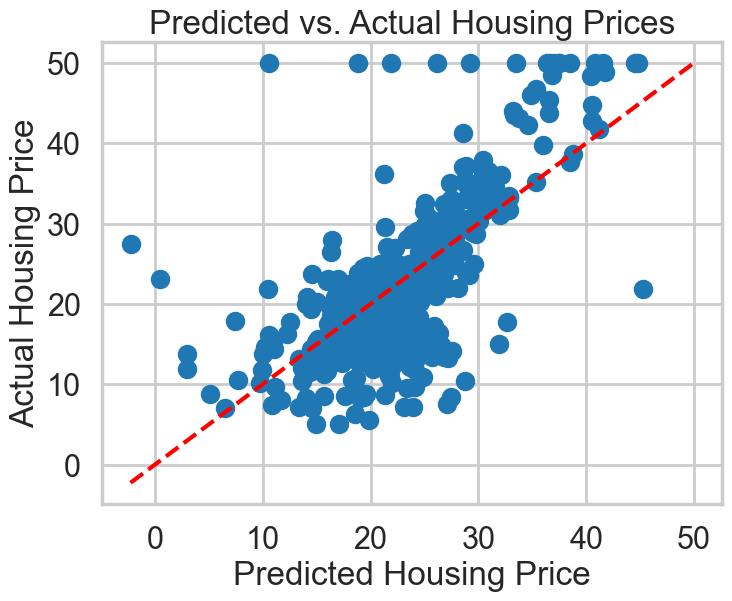

In [15]:
# Add a reference line representing perfect predictions.
# Points close to this line have small prediction errors.

plt.figure(figsize=(8, 6))

plt.scatter(m.fittedvalues, bos['PRICE'])

# Determine the range needed for the reference line.
min_value = min(m.fittedvalues.min(), bos['PRICE'].min())
max_value = max(m.fittedvalues.max(), bos['PRICE'].max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--', color='r'
)

plt.xlabel('Predicted Housing Price')
plt.ylabel('Actual Housing Price')
plt.title('Predicted vs. Actual Housing Prices')

plt.show()

<p><b>Answer:</b> The predicted and actual prices show a positive relationship, meaning the model generally predicts higher prices for homes that actually have higher prices. However, the points do not fall perfectly along the 45-degree line. There is noticeable variation, especially for expensive houses. The plot also shows a ceiling effect: the model tends to underpredict some of the highest housing prices. This suggests that a simple linear relationship between RM and PRICE does not completely explain the data.

### Fitting Linear Regression using `sklearn`


In [16]:
from sklearn.linear_model import LinearRegression
X = bos.drop('PRICE', axis = 1)

# This creates a LinearRegression object
lm = LinearRegression()
lm

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### What can you do with a LinearRegression object? 
***
Check out the scikit-learn [docs here](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html). We have listed the main functions here. Most machine learning models in scikit-learn follow this same API of fitting a model with `fit`, making predictions with `predict` and the appropriate scoring function `score` for each model.

Main functions | Description
--- | --- 
`lm.fit()` | Fit a linear model
`lm.predit()` | Predict Y using the linear model with estimated coefficients
`lm.score()` | Returns the coefficient of determination (R^2). *A measure of how well observed outcomes are replicated by the model, as the proportion of total variation of outcomes explained by the model*

#### What output can you get?

In [17]:
# Look inside lm object
# lm.<tab>

Output | Description
--- | --- 
`lm.coef_` | Estimated coefficients
`lm.intercept_` | Estimated intercept 

### Fit a linear model
***

The `lm.fit()` function estimates the coefficients the linear regression using least squares. 

In [18]:
# Use all 13 predictors to fit linear regression model
lm.fit(X, bos.PRICE)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0.11, 0.05, 0.02,...,-0.95, 0.01,-0.52]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['CRIM','ZN','INDUS',...,'PTRATIO','B','LSTAT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,36.46
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13


<div class="span5 alert alert-info">
<h3>Part 3 Checkup Exercise Set II</h3>

<p><b>Exercise:</b> How would you change the model to not fit an intercept term? Would you recommend not having an intercept? Why or why not? For more information on why to include or exclude an intercept, look [here](https://stats.idre.ucla.edu/other/mult-pkg/faq/general/faq-what-is-regression-through-the-origin/).</p>

<p><b>Exercise:</b> One of the assumptions of the linear model is that the residuals must be i.i.d. (independently and identically distributed). To satisfy this, is it enough that the residuals are normally distributed? Explain your answer.</p>

<p><b>Exercise:</b> True or false. To use linear regression, $Y$ must be normally distributed. Explain your answer.</p>
</div>


In [19]:
# Fit the multiple linear regression model without an intercept.
# fit_intercept=False tells sklearn not to estimate an intercept.

lm_no_intercept = LinearRegression(fit_intercept=False)

lm_no_intercept.fit(X, bos['PRICE'])

print('Intercept:', lm_no_intercept.intercept_)
print('Coefficients:', lm_no_intercept.coef_)

Intercept: 0.0
Coefficients: [-9.28965170e-02  4.87149552e-02 -4.05997958e-03  2.85399882e+00
 -2.86843637e+00  5.92814778e+00 -7.26933458e-03 -9.68514157e-01
  1.71151128e-01 -9.39621540e-03 -3.92190926e-01  1.49056102e-02
 -4.16304471e-01]


In [20]:
# Remove the intercept from the multiple regression model.
# "- 1" tells statsmodels not to include an intercept.

m_no_intercept = ols(
    'PRICE ~ CRIM + ZN + INDUS + CHAS + NOX + RM + AGE + DIS + RAD + TAX + PTRATIO + B + LSTAT - 1',
    data=bos
).fit()

print(m_no_intercept.summary())

                                 OLS Regression Results                                
Dep. Variable:                  PRICE   R-squared (uncentered):                   0.959
Model:                            OLS   Adj. R-squared (uncentered):              0.958
Method:                 Least Squares   F-statistic:                              891.3
Date:                Mon, 28 Sep 2026   Prob (F-statistic):                        0.00
Time:                        00:31:04   Log-Likelihood:                         -1523.8
No. Observations:                 506   AIC:                                      3074.
Df Residuals:                     493   BIC:                                      3128.
Df Model:                          13                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [21]:
# Remove the intercept from the multiple regression model.
# "- 1" tells statsmodels not to include an intercept.

m_no_intercept = ols(
    'PRICE ~ CRIM + ZN + INDUS + CHAS + NOX + RM + AGE + DIS + RAD + TAX + PTRATIO + B + LSTAT - 1',
    data=bos
).fit()

print(m_no_intercept.summary())

                                 OLS Regression Results                                
Dep. Variable:                  PRICE   R-squared (uncentered):                   0.959
Model:                            OLS   Adj. R-squared (uncentered):              0.958
Method:                 Least Squares   F-statistic:                              891.3
Date:                Mon, 28 Sep 2026   Prob (F-statistic):                        0.00
Time:                        00:31:04   Log-Likelihood:                         -1523.8
No. Observations:                 506   AIC:                                      3074.
Df Residuals:                     493   BIC:                                      3128.
Df Model:                          13                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

<p><b>Answer:</b> I would generally keep the intercept for this dataset. The intercept represents the predicted value of PRICE when all predictors are zero. Although zero may not be realistic for some predictors, the intercept is still useful for positioning the regression line appropriately. Removing the intercept forces the regression line through zero. That constraint should only be used when there is a strong theoretical reason to believe that the response must be zero when all predictors are zero.

<p><b>Answer:</b> No. Normally distributed residuals do not automatically mean that the residuals are independent and identically distributed. 

The i.i.d. assumption requires:
1) Independent — one observation's residual does not depend on another observation's residual.
2) Identically distributed — residuals have the same underlying distribution, including consistent variance.

Residuals can be normally distributed but still be correlated with each other.
For example, time-series observations can have normally distributed errors that are nevertheless correlated over time.

<p><b>Answer:</b> False. The dependent variable Y itself does not have to be normally distributed.

The classical linear regression assumption concerns the errors/residuals, which are assumed to be approximately normally distributed for certain inference procedures.

For example, a response variable can be skewed while the residuals from an appropriate regression model are approximately normally distributed.

### Estimated intercept and coefficients

Let's look at the estimated coefficients from the linear model using `1m.intercept_` and `lm.coef_`.  

After we have fit our linear regression model using the least squares method, we want to see what are the estimates of our coefficients $\beta_0$, $\beta_1$, ..., $\beta_{13}$: 

$$ \hat{\beta}_0, \hat{\beta}_1, \ldots, \hat{\beta}_{13} $$



In [22]:
print('Estimated intercept coefficient: {}'.format(lm.intercept_))

Estimated intercept coefficient: 36.4594883850902


In [23]:
print('Number of coefficients: {}'.format(len(lm.coef_)))

Number of coefficients: 13


In [24]:
# The coefficients
pd.DataFrame({'features': X.columns, 'estimatedCoefficients': lm.coef_})[['features', 'estimatedCoefficients']]

,features,estimatedCoefficients
0,CRIM,-0.108011
1,ZN,0.046420
2,INDUS,0.020559
3,CHAS,2.686734
4,NOX,-17.766611
5,RM,3.809865
6,AGE,0.000692
7,DIS,-1.475567
8,RAD,0.306049
9,TAX,-0.012335


### Predict Prices 

We can calculate the predicted prices ($\hat{Y}_i$) using `lm.predict`. 

$$ \hat{Y}_i = \hat{\beta}_0 + \hat{\beta}_1 X_1 + \ldots \hat{\beta}_{13} X_{13} $$

In [25]:
# first five predicted prices
lm.predict(X)[0:5]

array([30.00384338, 25.02556238, 30.56759672, 28.60703649, 27.94352423])

<div class="span5 alert alert-info">
<h3>Part 3 Checkup Exercise Set III</h3>

<p><b>Exercise:</b> Histogram: Plot a histogram of all the predicted prices. Write a story about what you see. Describe the shape, center and spread of the distribution. Are there any outliers? What might be the reason for them? Should we do anything special with them?</p>

<p><b>Exercise:</b> Scatterplot: Let's plot the true prices compared to the predicted prices to see they disagree (we did this with `statsmodels` before).</p>

<p><b>Exercise:</b> We have looked at fitting a linear model in both `statsmodels` and `scikit-learn`. What are the advantages and disadvantages of each based on your exploration? Based on the information provided by both packages, what advantage does `statsmodels` provide?</p>
</div>

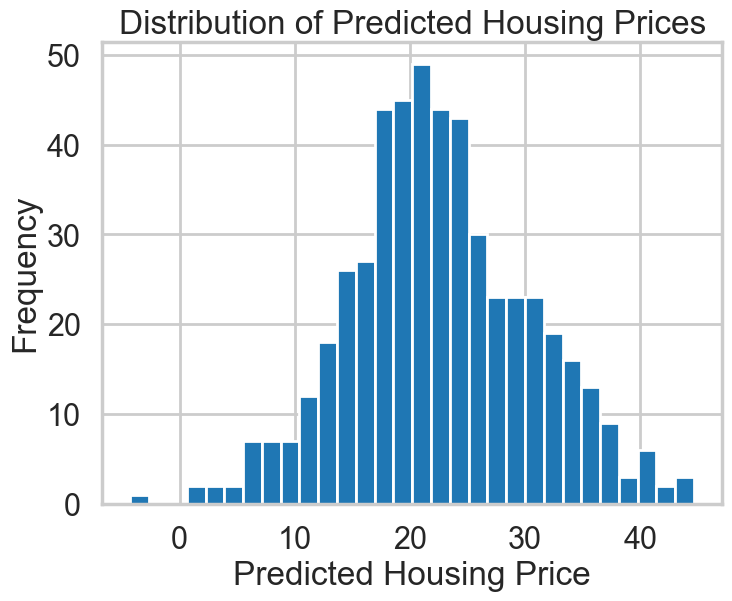

In [26]:
# your turn

# Histogram
# Generate predictions for every observation.
predicted_prices = lm.predict(X)

# Plot the distribution of predicted housing prices.

plt.figure(figsize=(8, 6))

plt.hist(predicted_prices, bins=30)

plt.xlabel('Predicted Housing Price')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Housing Prices')

plt.show()


<p><b>Answer:</b> The predicted-price distribution is concentrated around the middle of the housing-price range, with most predictions falling around the typical values in the dataset. The distribution has a moderate spread and includes some relatively high predicted prices. These high predictions are not automatically outliers or errors; they may correspond to neighborhoods with favorable combinations of predictor values. We should investigate unusual observations rather than automatically removing them.

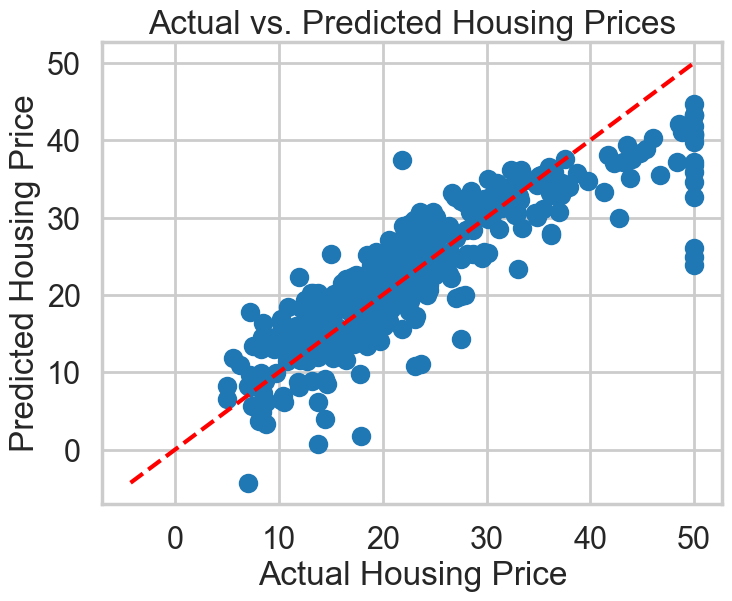

In [27]:
# Scatterplot
# Compare actual housing prices with model predictions.

plt.figure(figsize=(8, 6))

plt.scatter(
    bos['PRICE'],
    predicted_prices
)

# Add a reference line representing perfect prediction.
min_value = min(bos['PRICE'].min(), predicted_prices.min())
max_value = max(bos['PRICE'].max(), predicted_prices.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--', color='r'
)

plt.xlabel('Actual Housing Price')
plt.ylabel('Predicted Housing Price')
plt.title('Actual vs. Predicted Housing Prices')

plt.show()

<p><b>Answer:</b> Actual and predicted prices have a strong positive relationship, indicating that the model generally captures the overall variation in housing prices. Points close to the diagonal line represent more accurate predictions, while points farther from the line represent larger prediction errors. The model does not predict every observation equally well, particularly at the extremes of the price range.

<p><b>Answer:</b> statsmodels is especially useful when you want to understand the statistical significance and uncertainty of your model. For example, it provides coefficient estimates, standard errors, t-statistics, p-values, confidence intervals, F-statistics, AIC, detailed regression summaries. scikit-learn is particularly useful for machine-learning workflows, especially prediction, train/test splitting, preprocessing, cross-validation, and comparing models.

### Evaluating the Model: Sum-of-Squares

The partitioning of the sum-of-squares shows the variance in the predictions explained by the model and the variance that is attributed to error.

$$TSS = ESS + RSS$$

#### Residual Sum-of-Squares (aka $RSS$)

The residual sum-of-squares is one of the basic ways of quantifying how much error exists in the fitted model. We will revisit this in a bit.

$$ RSS = \sum_{i=1}^N r_i^2 = \sum_{i=1}^N \left(y_i - \left(\beta_0 + \beta_1 x_i\right)\right)^2 $$

In [28]:
print(np.sum((bos.PRICE - lm.predict(X)) ** 2))

11078.784577954979


#### Explained Sum-of-Squares (aka $ESS$)

The explained sum-of-squares measures the variance explained by the regression model.

$$ESS = \sum_{i=1}^N \left( \hat{y}_i - \bar{y} \right)^2 = \sum_{i=1}^N \left( \left( \hat{\beta}_0 + \hat{\beta}_1 x_i \right) - \bar{y} \right)^2$$

In [29]:
print(np.sum((lm.predict(X) - np.mean(bos.PRICE)) ** 2))

31637.5108370648


### Evaluating the Model: The Coefficient of Determination ($R^2$)

The coefficient of determination, $R^2$, tells us the percentage of the variance in the response variable $Y$ that can be explained by the linear regression model.

$$ R^2 = \frac{ESS}{TSS} $$

The $R^2$ value is one of the most common metrics that people use in describing the quality of a model, but it is important to note that *$R^2$ increases artificially as a side-effect of increasing the number of independent variables.* While $R^2$ is reported in almost all statistical packages, another metric called the *adjusted $R^2$* is also provided as it takes into account the number of variables in the model, and can sometimes even be used for non-linear regression models!

$$R_{adj}^2 = 1 - \left( 1 - R^2 \right) \frac{N - 1}{N - K - 1} = R^2 - \left( 1 - R^2 \right) \frac{K}{N - K - 1} = 1 - \frac{\frac{RSS}{DF_R}}{\frac{TSS}{DF_T}}$$

where $N$ is the number of observations, $K$ is the number of variables, $DF_R = N - K - 1$ is the degrees of freedom associated with the residual error and $DF_T = N - 1$ is the degrees of the freedom of the total error.

### Evaluating the Model: Mean Squared Error and the $F$-Statistic
***
The mean squared errors are just the *averages* of the sum-of-squares errors over their respective degrees of freedom.

$$MSE = \frac{RSS}{N-K-1}$$

$$MSR = \frac{ESS}{K}$$

**Remember:** Notation may vary across resources particularly the use of $R$ and $E$ in $RSS/ESS$ and $MSR/MSE$. In some resources, E = explained and R = residual. In other resources, E = error and R = regression (explained). **This is a very important distinction that requires looking at the formula to determine which naming scheme is being used.**

Given the MSR and MSE, we can now determine whether or not the entire model we just fit is even statistically significant. We use an $F$-test for this. The null hypothesis is that all of the $\beta$ coefficients are zero, that is, none of them have any effect on $Y$. The alternative is that *at least one* $\beta$ coefficient is nonzero, but it doesn't tell us which one in a multiple regression:

$$H_0: \beta_i = 0, \mbox{for all $i$} \\
H_A: \beta_i > 0, \mbox{for some $i$}$$ 

$$F = \frac{MSR}{MSE} = \left( \frac{R^2}{1 - R^2} \right) \left( \frac{N - K - 1}{K} \right)$$
 
Once we compute the $F$-statistic, we can use the $F$-distribution with $N-K$ and $K-1$ degrees of degrees of freedom to get a p-value.

**Warning!** The $F$-statistic mentioned in this section is NOT the same as the F1-measure or F1-value discused in Unit 7.

<div class="span5 alert alert-info">
<h3>Part 3 Checkup Exercise Set IV</h3>

<p>Let's look at the relationship between `PTRATIO` and housing price.</p>

<p><b>Exercise:</b> Try fitting a linear regression model using only the 'PTRATIO' (pupil-teacher ratio by town) and interpret the intercept and the coefficients.</p>

<p><b>Exercise:</b> Calculate (or extract) the $R^2$ value. What does it tell you?</p>

<p><b>Exercise:</b> Compute the $F$-statistic. What does it tell you?</p>

<p><b>Exercise:</b> Take a close look at the $F$-statistic and the $t$-statistic for the regression coefficient. What relationship do you notice? Note that this relationship only applies in *simple* linear regression models.</p>
</div>

In [30]:
# your turn
# Fit a simple linear regression model using only PTRATIO.

ptratio_model = ols(
    'PRICE ~ PTRATIO',
    data=bos
).fit()

# Display the regression results.
print(ptratio_model.summary())

# Extract the intercept and PTRATIO coefficient.

print('Intercept:', ptratio_model.params['Intercept'])
print('PTRATIO coefficient:', ptratio_model.params['PTRATIO'])

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.256
Method:                 Least Squares   F-statistic:                     175.1
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           1.61e-34
Time:                        00:31:04   Log-Likelihood:                -1764.8
No. Observations:                 506   AIC:                             3534.
Df Residuals:                     504   BIC:                             3542.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     62.3446      3.029     20.581      0.0

<p><b>Answer:</b> The estimated intercept is approximately 62.34. This represents the predicted housing price when PTRATIO equals 0, although a pupil-to-teacher ratio of zero is not realistic and therefore the intercept has limited practical interpretation.

The PTRATIO coefficient is approximately −2.16. Holding the model structure constant, a one-unit increase in PTRATIO is associated with an estimated decrease of about 2.16 units in PRICE. Because PRICE is measured in thousands of dollars, this corresponds to approximately $2,157. The relationship is an association and does not establish causation.

In [31]:
# Calculate (or extract) the R² value
print('R-squared:', ptratio_model.rsquared)

R-squared: 0.2578473180092229


<p><b>Answer:</b> R² is approximately 0.258, meaning that PTRATIO alone explains about 25.8% of the variation in housing prices in this sample. The remaining variation is explained by other factors and random error. Therefore, PTRATIO has a measurable relationship with PRICE, but it does not explain most of the variation by itself.

In [32]:
# Extract the F-statistic and its p-value.

print('F-statistic:', ptratio_model.fvalue)
print('F-test p-value:', ptratio_model.f_pvalue)

F-statistic: 175.10554287569536
F-test p-value: 1.609509478473047e-34


<p><b>Answer:</b> The F-statistic tests whether the regression model with PTRATIO explains significantly more variation in PRICE than an intercept-only model. The F-statistic is approximately 175.1, with a very small p-value. Therefore, there is strong statistical evidence that the PTRATIO coefficient is not zero in this sample.

In [33]:
# Extract the t-statistic for the PTRATIO coefficient.

t_stat = ptratio_model.tvalues['PTRATIO']

# In simple linear regression, F = t^2.
print('t-statistic:', t_stat)
print('t-statistic squared:', t_stat ** 2)
print('F-statistic:', ptratio_model.fvalue)

t-statistic: -13.232745099777869
t-statistic squared: 175.1055428756952
F-statistic: 175.10554287569536


<p><b>Answer:</b In simple linear regression, the relationship is:

$$ F = t^2 $$

Therefore, the F-statistic and the squared t-statistic should be essentially the same. This relationship applies to simple linear regression with one predictor. It does not generally apply this way when there are multiple predictors.

<div class="span5 alert alert-info">
<h3>Part 3 Checkup Exercise Set V</h3>

<p>Fit a linear regression model using three independent variables</p>

<ol>
<li> 'CRIM' (per capita crime rate by town)
<li> 'RM' (average number of rooms per dwelling)
<li> 'PTRATIO' (pupil-teacher ratio by town)
</ol>

<p><b>Exercise:</b> Compute or extract the $F$-statistic. What does it tell you about the model?</p>

<p><b>Exercise:</b> Compute or extract the $R^2$ statistic. What does it tell you about the model?</p>

<p><b>Exercise:</b> Which variables in the model are significant in predicting house price? Write a story that interprets the coefficients.</p>
</div>

In [34]:
# your turn
# Fit a multiple linear regression model using
# CRIM, RM, and PTRATIO.

model_3 = ols(
    'PRICE ~ CRIM + RM + PTRATIO',
    data=bos
).fit()

# Display the regression results.
print(model_3.summary())

# Extract the overall F-statistic.
print('F-statistic:', model_3.fvalue)

# Extract the F-test p-value.
print('F-test p-value:', model_3.f_pvalue)


                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.594
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     245.2
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           6.15e-98
Time:                        00:31:04   Log-Likelihood:                -1612.0
No. Observations:                 506   AIC:                             3232.
Df Residuals:                     502   BIC:                             3249.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.3707      4.034     -0.836      0.4

<p><b>Answer:</b> The overall F-test evaluates whether the regression model containing CRIM, RM, and PTRATIO provides information about PRICE beyond an intercept-only model. The very small p-value provides strong evidence that at least one of these predictors has a nonzero coefficient. The F-test does not tell us which individual predictors are significant; their individual p-values must be examined separately.

In [35]:
# Extract R-squared and adjusted R-squared.

print('R-squared:', model_3.rsquared)
print('Adjusted R-squared:', model_3.rsquared_adj)

R-squared: 0.5943412940723471
Adjusted R-squared: 0.59191703885764


<p><b>Answer:</b> The R² is approximately 0.593, meaning that CRIM, RM, and PTRATIO together explain about 59.3% of the variation in housing prices in this sample. The adjusted R² accounts for the number of predictors and is useful when comparing models with different numbers of predictors.

In [36]:
# Create a cleaner coefficient table.

coefficient_table = pd.DataFrame({
    'Coefficient': model_3.params,
    'P-value': model_3.pvalues,
    'Lower CI': model_3.conf_int()[0],
    'Upper CI': model_3.conf_int()[1]
})

coefficient_table

coefficient_table['Significant'] = (
    coefficient_table['P-value'] < 0.05
)

coefficient_table

,Coefficient,P-value,Lower CI,Upper CI,Significant
Intercept,-3.370704,4.037709e-01,-11.295947,4.554539,False
CRIM,-0.204961,3.592328e-10,-0.267891,-0.142030,True
RM,7.380411,4.413335e-58,6.591569,8.169253,True
PTRATIO,-1.069546,5.986964e-15,-1.330542,-0.808551,True


<p><b>Answer:</b> At the 0.05 significance level, the individual p-values should be examined to determine which predictors are statistically significant. CRIM has a negative coefficient, RM has a positive coefficient, and PTRATIO has a negative coefficient.

For each predictor, the coefficient represents its association with PRICE while holding the other two predictors constant. For example, the RM coefficient represents the expected change in PRICE associated with a one-unit increase in RM while CRIM and PTRATIO are held constant.

Statistical significance does not establish causation.

## Part 4: Comparing Models

During modeling, there will be times when we want to compare models to see which one is more predictive or fits the data better. There are many ways to compare models, but we will focus on two.

### The $F$-Statistic Revisited

The $F$-statistic can also be used to compare two *nested* models, that is, two models trained on the same dataset where one of the models contains a *subset* of the variables of the other model. The *full* model contains $K$ variables and the *reduced* model contains a subset of these $K$ variables. This allows us to add additional variables to a base model and then test if adding the variables helped the model fit.

$$F = \frac{\left( \frac{RSS_{reduced} - RSS_{full}}{DF_{reduced} - DF_{full}} \right)}{\left( \frac{RSS_{full}}{DF_{full}} \right)}$$

where $DF_x = N - K_x - 1$ where $K_x$ is the number of variables in model $x$.

### Akaike Information Criterion (AIC)

Another statistic for comparing two models is AIC, which is based on the likelihood function and takes into account the number of variables in the model.

$$AIC = 2 K - 2 \log_e{L}$$

where $L$ is the likelihood of the model. AIC is meaningless in the absolute sense, and is only meaningful when compared to AIC values from other models. Lower values of AIC indicate better fitting models.

`statsmodels` provides the AIC in its output.

<div class="span5 alert alert-info">
<h3>Part 4 Checkup Exercises</h3>

<p><b>Exercise:</b> Find another variable (or two) to add to the model we built in Part 3. Compute the $F$-test comparing the two models as well as the AIC. Which model is better?</p>
</div>

In [37]:
# Reduced model from Part 3:
# PRICE predicted by CRIM, RM, and PTRATIO.

reduced_model = ols(
    'PRICE ~ CRIM + RM + PTRATIO',
    data=bos
).fit()

# Full model:
# Add LSTAT to the three original predictors.

full_model = ols(
    'PRICE ~ CRIM + RM + PTRATIO + LSTAT',
    data=bos
).fit()

# Display AIC values.
print('Reduced model AIC:', reduced_model.aic)
print('Full model AIC:', full_model.aic)

# Compare the two nested models using an F-test.
anova_results = sm.stats.anova_lm(
    reduced_model,
    full_model
)

print(anova_results)

Reduced model AIC: 3231.9451235449956
Full model AIC: 3111.5610897408874
   df_resid           ssr  df_diff      ss_diff           F        Pr(>F)
0     502.0  17328.237120      0.0          NaN         NaN           NaN
1     501.0  13605.466968      1.0  3722.770152  137.085177  3.714456e-28


<p><b>Answer:</b> Adding LSTAT significantly improves the in-sample fit of the model. The nested-model F-test produces a very small p-value, providing evidence that LSTAT adds information beyond CRIM, RM, and PTRATIO. The full model also has a substantially lower AIC, which supports the four-predictor model under the AIC criterion. However, these results evaluate in-sample fit; a train/test split or cross-validation would be needed to determine whether the additional predictor improves out-of-sample predictive performance.


## Part 5: Evaluating the Model via Model Assumptions and Other Issues
***
Linear regression makes several assumptions. It is always best to check that these assumptions are valid after fitting a linear regression model.

<div class="span5 alert alert-danger">
<ul>
  <li>**Linearity**. The dependent variable $Y$ is a linear combination of the regression coefficients and the independent variables $X$. This can be verified with a scatterplot of each $X$ vs. $Y$ and plotting correlations among $X$. Nonlinearity can sometimes be resolved by [transforming](https://onlinecourses.science.psu.edu/stat501/node/318) one or more independent variables, the dependent variable, or both. In other cases, a [generalized linear model](https://en.wikipedia.org/wiki/Generalized_linear_model) or a [nonlinear model](https://en.wikipedia.org/wiki/Nonlinear_regression) may be warranted.</li>
  <li>**Constant standard deviation**. The SD of the dependent variable $Y$ should be constant for different values of X. We can check this by plotting each $X$ against $Y$ and verifying that there is no "funnel" shape showing data points fanning out as $X$ increases or decreases. Some techniques for dealing with non-constant variance include weighted least squares (WLS), [robust standard errors](https://en.wikipedia.org/wiki/Heteroscedasticity-consistent_standard_errors), or variance stabilizing transformations.
    </li>
  <li> **Normal distribution for errors**.  The $\epsilon$ term we discussed at the beginning are assumed to be normally distributed. This can be verified with a fitted values vs. residuals plot and verifying that there is no pattern, and with a quantile plot.
  $$ \epsilon_i \sim N(0, \sigma^2)$$
Sometimes the distributions of responses $Y$ may not be normally distributed at any given value of $X$.  e.g. skewed positively or negatively. </li>
<li> **Independent errors**.  The observations are assumed to be obtained independently.
    <ul>
        <li>e.g. Observations across time may be correlated
    </ul>
</li>
</ul>  

</div>

There are some other issues that are important investigate with linear regression models.

<div class="span5 alert alert-danger">
<ul>
  <li>**Correlated Predictors:** Care should be taken to make sure that the independent variables in a regression model are not too highly correlated. Correlated predictors typically do not majorly affect prediction, but do inflate standard errors of coefficients making interpretation unreliable. Common solutions are dropping the least important variables involved in the correlations, using regularlization, or, when many predictors are highly correlated, considering a dimension reduction technique such as principal component analysis (PCA).
  <li>**Influential Points:** Data points that have undue influence on the regression model. These points can be high leverage points or outliers. Such points are typically removed and the regression model rerun.
</ul>
</div>


<div class="span5 alert alert-info">
<h3>Part 5 Checkup Exercises</h3>

<p>Take the reduced model from Part 3 to answer the following exercises. Take a look at [this blog post](http://mpastell.com/2013/04/19/python_regression/) for more information on using statsmodels to construct these plots.</p>
    
<p><b>Exercise:</b> Construct a fitted values versus residuals plot. What does the plot tell you? Are there any violations of the model assumptions?</p>

<p><b>Exercise:</b> Construct a quantile plot of the residuals. What does the plot tell you?</p>

<p><b>Exercise:</b> What are some advantages and disadvantages of the fitted vs. residual and quantile plot compared to each other?</p>

<p><b>Exercise:</b> Identify any outliers (if any) in your model and write a story describing what these outliers might represent.</p>

<p><b>Exercise:</b> Construct a leverage plot and identify high leverage points in the model. Write a story explaining possible reasons for the high leverage points.</p>

<p><b>Exercise:</b> Remove the outliers and high leverage points from your model and run the regression again. How do the results change?</p>
</div>

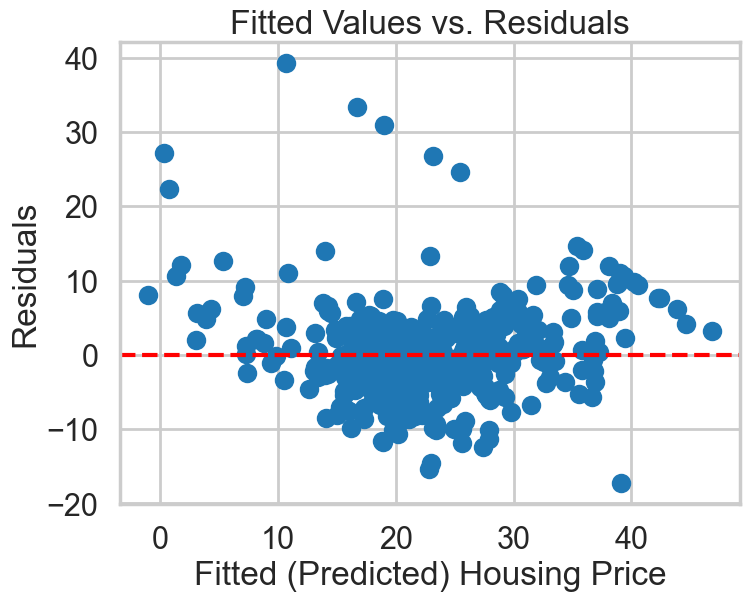

In [38]:
# Your turn.
# Calculate residuals from the reduced three-variable model.
# A residual is:
# actual PRICE - predicted PRICE.

fitted_values = model_3.fittedvalues
residuals = model_3.resid

# Plot fitted values against residuals.

plt.figure(figsize=(8, 6))

plt.scatter(fitted_values, residuals)

# Add a horizontal line at zero.
# Ideally, residuals should be randomly scattered around zero.

plt.axhline(
    y=0,
    linestyle='--', color='r'
)

plt.xlabel('Fitted (Predicted) Housing Price')
plt.ylabel('Residuals')
plt.title('Fitted Values vs. Residuals')

plt.show()



<p><b>Answer:</b> The residuals are generally centered around zero, but the spread of the residuals is not perfectly constant across the fitted values. There are also some unusually large residuals. These features suggest that the linear model assumptions may not be perfectly satisfied, particularly the constant-variance assumption. The plot alone cannot establish the cause of these patterns, so additional diagnostic tests or plots should be considered.

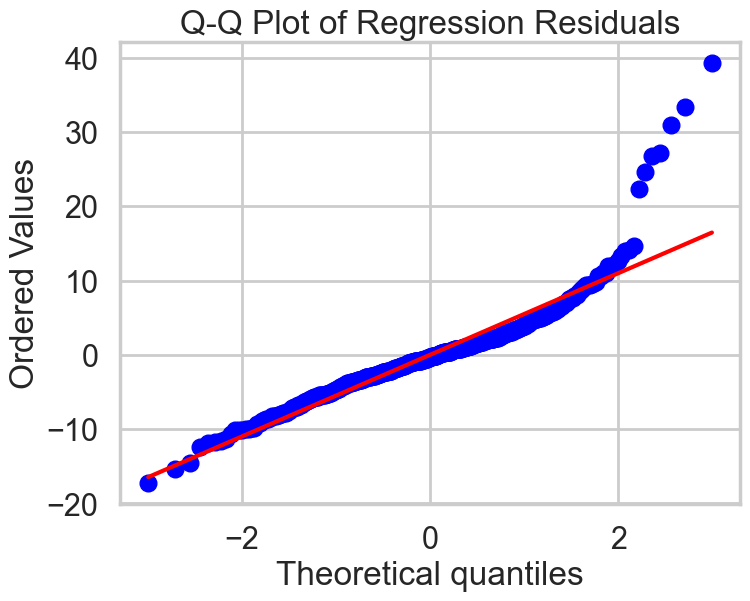

In [39]:
# Create a Q-Q plot to compare the residual distribution
# with a theoretical normal distribution.

plt.figure(figsize=(8, 6))

stats.probplot(
    residuals,
    dist='norm',
    plot=plt
)

plt.title('Q-Q Plot of Regression Residuals')

plt.show()

<p><b>Answer:</b> If the residuals are normally distributed, the points should approximately follow the straight reference line. 
Departures from the line, particularly at the tails, indicate departures from normality.
For this dataset, the residuals are not perfectly normal, with noticeable deviations at the tails.
This suggests that there are some unusually large positive or negative residuals.

<p><b>Answer:</b> 

**Fitted values vs. residuals**

* Detects nonlinearity, heteroscedasticity, and unusual patterns/outliers.
* Does not directly assess normality and can sometimes be difficult to interpret.

**Q-Q plot**

* Assesses whether residuals are approximately normally distributed, especially in the tails.
* Does not show heteroscedasticity or residual patterns well.

**Overall:**
The plots serve different purposes, so **both should be used together** for regression diagnostics.


In [40]:
# Identify Outliers
# Calculate standardized residuals.
# Large absolute values indicate observations whose
# residuals are unusually large compared with the others.

influence = model_3.get_influence()

standardized_residuals = influence.resid_studentized_internal

# Add standardized residuals to the dataframe temporarily.
diagnostics = bos.copy()

diagnostics['standardized_residual'] = standardized_residuals

# Find observations with absolute standardized residual > 2.
# These are potential outliers for investigation.

potential_outliers = diagnostics[
    diagnostics['standardized_residual'].abs() > 2
]

print(
    potential_outliers[
        ['CRIM', 'RM', 'PTRATIO', 'PRICE', 'standardized_residual']
    ].sort_values(
        'standardized_residual',
        key=lambda x: x.abs(),
        ascending=False
    )
)

         CRIM     RM  PTRATIO  PRICE  standardized_residual
368   4.89822  4.970     20.2   50.0               6.719690
372   8.26725  5.875     20.2   50.0               5.679861
371   9.23230  6.216     20.2   50.0               5.284871
365   4.55587  3.561     20.2   27.5               4.696069
369   5.66998  6.683     20.2   50.0               4.575289
370   6.53876  7.016     20.2   50.0               4.191566
367  13.52220  3.863     20.2   23.1               3.853096
364   3.47428  8.780     20.2   21.9              -2.985089
416  10.83420  6.782     20.2    7.5              -2.622795
186   0.05602  7.831     17.8   50.0               2.504300
419  11.81230  6.824     20.2    8.4              -2.488679
161   1.46336  7.489     14.7   50.0               2.416836
407  11.95110  5.608     20.2   27.9               2.378149
181   0.06888  6.144     17.8   36.2               2.262927
412  18.81100  4.628     20.2   17.9               2.158097
10    0.22489  6.377     15.2   15.0    

<p><b>Answer:</b> Using an absolute standardized residual greater than 2 as a screening rule identifies several potential outliers. These observations have housing prices that differ substantially from the values predicted by the three-variable model. However, they should be treated as potential outliers rather than automatically classified as erroneous observations. They may represent genuinely unusual neighborhoods, unusual housing characteristics, or observations not adequately explained by the three predictors.

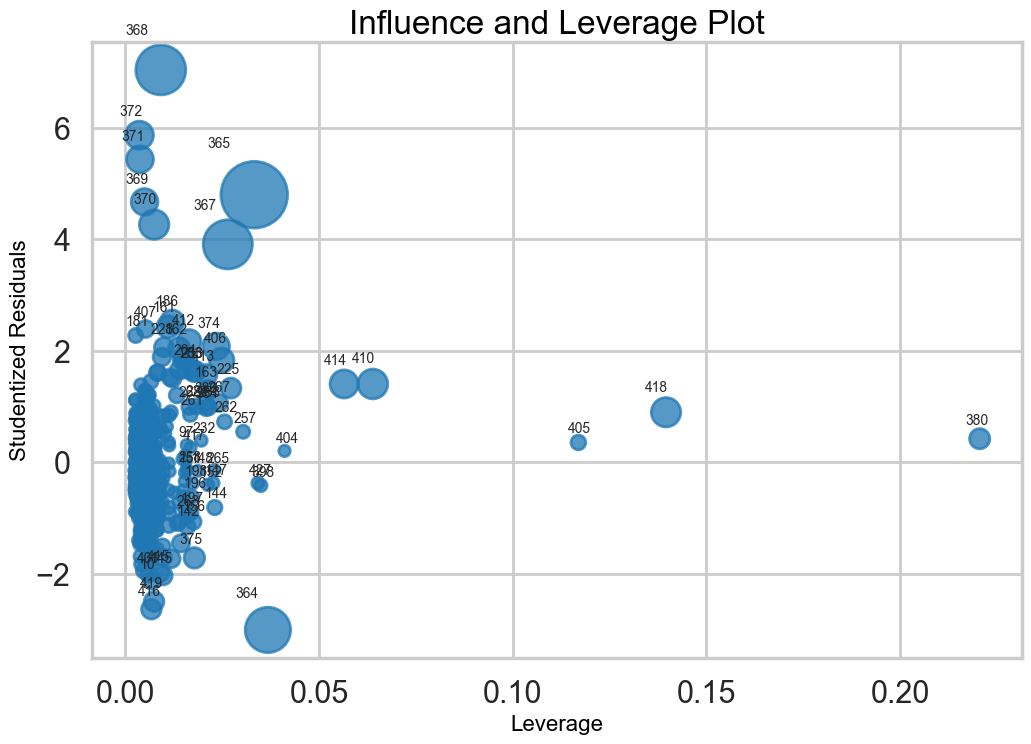

In [41]:
# Create a leverage/influence plot.
# This helps identify observations that have unusual
# predictor values and may strongly influence the regression.

fig, ax = plt.subplots(figsize=(12, 8))

sm.graphics.influence_plot(
    model_3,
    ax=ax,
    criterion='cooks'
)

# Reduce the size of the observation number labels
for text in ax.texts:
    text.set_fontsize(10)
    
plt.title('Influence and Leverage Plot')

plt.show()


In [42]:
# Extract influence diagnostics.
influence = model_3.get_influence()

# Leverage measures how unusual an observation's predictor values are.
leverage = influence.hat_matrix_diag

# Cook's distance measures how much an observation influences
# the fitted regression model.
cooks_distance = influence.cooks_distance[0]

diagnostics = bos[
    ['CRIM', 'RM', 'PTRATIO', 'PRICE']
].copy()

diagnostics['leverage'] = leverage
diagnostics['Cook_D'] = cooks_distance

# Common screening threshold for leverage:
# 2 * (number of parameters) / number of observations.
# The model has 3 predictors + 1 intercept = 4 parameters.
n = len(bos)
p = 4

leverage_threshold = 2 * p / n

high_leverage = diagnostics[
    diagnostics['leverage'] > leverage_threshold
].sort_values('leverage', ascending=False)

high_leverage.head(10)

,CRIM,RM,PTRATIO,PRICE,leverage,Cook_D
380,88.97620,6.968,20.2,10.4,0.220554,0.012558
418,73.53410,5.957,20.2,8.8,0.139582,0.032546
405,67.92080,5.683,20.2,5.0,0.116949,0.004146
410,51.13580,5.757,20.2,15.0,0.063889,0.033519
414,45.74610,4.519,20.2,7.0,0.056465,0.029396
404,41.52920,5.531,20.2,8.5,0.041087,0.000440
364,3.47428,8.780,20.2,21.9,0.036799,0.085110
398,38.35180,5.453,20.2,5.0,0.034959,0.001578
427,37.66190,6.202,20.2,10.9,0.034205,0.001261
365,4.55587,3.561,20.2,27.5,0.033270,0.189738


<p><b>Answer:</b> The leverage analysis identifies observations whose CRIM, RM, and/or PTRATIO values are unusually different from the rest of the dataset. These observations have relatively high leverage and therefore have greater potential to influence the fitted regression coefficients. High leverage does not automatically mean that an observation is an error or should be removed. Each observation should be investigated before deciding how to handle it.

In [43]:
# Create a copy containing the diagnostic measures.
diagnostics = bos.copy()

diagnostics['standardized_residual'] = (
    influence.resid_studentized_internal
)

diagnostics['leverage'] = (
    influence.hat_matrix_diag
)

diagnostics['Cook_D'] = (
    influence.cooks_distance[0]
)

# Flag observations for investigation.
outlier_mask = (
    diagnostics['standardized_residual'].abs() > 2
)

high_leverage_mask = (
    diagnostics['leverage'] > leverage_threshold
)

# Combine the screening criteria.
flagged_mask = outlier_mask | high_leverage_mask

# Create a sensitivity-analysis dataset.
bos_sensitivity = bos.loc[~flagged_mask].copy()

print('Original observations:', len(bos))
print('Flagged observations:', flagged_mask.sum())
print('Remaining observations:', len(bos_sensitivity))

# Refit the same model after excluding flagged observations.
sensitivity_model = ols(
    'PRICE ~ CRIM + RM + PTRATIO',
    data=bos_sensitivity
).fit()

print(sensitivity_model.summary())

Original observations: 506
Flagged observations: 62
Remaining observations: 444
                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.733
Model:                            OLS   Adj. R-squared:                  0.731
Method:                 Least Squares   F-statistic:                     402.1
Date:                Mon, 28 Sep 2026   Prob (F-statistic):          1.20e-125
Time:                        00:31:04   Log-Likelihood:                -1214.5
No. Observations:                 444   AIC:                             2437.
Df Residuals:                     440   BIC:                             2453.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

In [44]:
# Compare the original model with the sensitivity model.

comparison = pd.DataFrame({
    'Original': [
        model_3.rsquared,
        model_3.rsquared_adj,
        model_3.aic,
        model_3.fvalue,
        model_3.f_pvalue
    ],
    'Sensitivity Analysis': [
        sensitivity_model.rsquared,
        sensitivity_model.rsquared_adj,
        sensitivity_model.aic,
        sensitivity_model.fvalue,
        sensitivity_model.f_pvalue
    ]
}, index=[
    'R-squared',
    'Adjusted R-squared',
    'AIC',
    'F-statistic',
    'F-test p-value'
])

comparison

,Original,Sensitivity Analysis
R-squared,5.943413e-01,7.327506e-01
Adjusted R-squared,5.919170e-01,7.309285e-01
AIC,3.231945e+03,2.437035e+03
F-statistic,2.451645e+02,4.021341e+02
F-test p-value,6.150435e-98,1.199270e-125


<p><b>Answer:</b> The model was refitted after excluding observations flagged by the residual and leverage screening rules. The resulting coefficients and model statistics should be compared with the original model. Large changes in the coefficients would indicate that the flagged observations have substantial influence on the estimated relationships.

However, these observations should not automatically be deleted. A large residual or high leverage may represent a genuine characteristic of a neighborhood rather than a data error. The comparison is therefore best treated as a sensitivity analysis.